In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

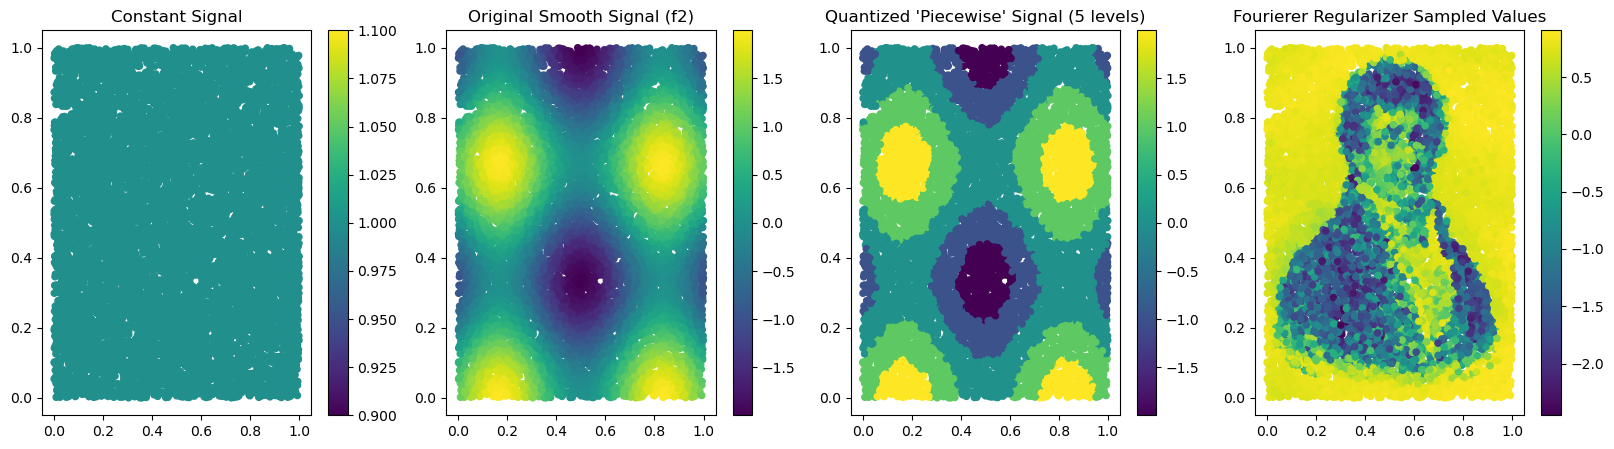

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from infidictionary.regularizers import FouriererRegularizer

reg_fourierer = FouriererRegularizer(asset_path="../assets/Joseph_Fourier.jpg", resize_to=512)

# Setup (Handling imports and device for standalone running)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N = 10000
Freq = 3

# get a constant signal
coords = torch.rand(N, 2, device=device)
f1 = torch.ones(coords.shape[0], device=device)

# f2: The continuous smooth signal
f2 = torch.sin(coords[:, 0] * Freq * np.pi) + torch.cos(coords[:, 1] * Freq * np.pi)

# --- START QUANTIZATION LOGIC ---
# Goal: Map the continuous f2 to a discrete set of 'num_levels' values
num_levels = 5  # Fewer levels = more obvious "staircase" effect

# 1. Determine the dynamic range of the signal
min_val = f2.min()
max_val = f2.max()

# 2. Calculate the step size (distance between quantization levels)
step_size = (max_val - min_val) / (num_levels - 1)

# 3. Quantize
# Formula: round((x - min) / step) * step + min
# This maps the values to integer indices [0, num_levels-1] and scales them back
f3_indices = torch.round((f2 - min_val) / step_size)
f3 = f3_indices * step_size + min_val
# --- END QUANTIZATION LOGIC ---

# Visualization
f1_np = f1.detach().cpu().numpy()
f2_np = f2.detach().cpu().numpy()
f3_np = f3.detach().cpu().numpy()

f4 = reg_fourierer.get_joseph(coords)
f4_np = f4.detach().cpu().numpy()

x = coords[:, 0].detach().cpu().numpy()
y = coords[:, 1].detach().cpu().numpy()

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.scatter(x, y, c=f1_np, s=20, cmap='viridis')
plt.title("Constant Signal")
plt.colorbar()

plt.subplot(1, 4, 2)
plt.scatter(x, y, c=f2_np, s=20, cmap='viridis')
plt.title("Original Smooth Signal (f2)")
plt.colorbar()

plt.subplot(1, 4, 3)
plt.scatter(x, y, c=f3_np, s=20, cmap='viridis')
plt.title(f"Quantized 'Piecewise' Signal ({num_levels} levels)")
plt.colorbar()

plt.subplot(1, 4, 4)
plt.scatter(x, y, c=f4_np, s=20, cmap='viridis')
plt.title("Fourierer Regularizer Sampled Values")
plt.colorbar()

plt.show()

In [3]:
from infidictionary.regularizers import FouriererRegularizer, EntropyRegularizer

reg_entropy = EntropyRegularizer(sigma=0.1)

F = torch.stack([f1, f2, f3, f4], dim=0)
entropy_energy = reg_entropy.compute_energy(coords, F)
fourierer_energy = reg_fourierer.compute_energy(coords, F)

print("Entropy energy", entropy_energy)
print("Fourierer energy", fourierer_energy)

Entropy energy tensor([-1.0000e-08,  2.6990e+00,  1.4381e+00,  2.0530e+00], device='cuda:0')
Fourierer energy tensor([1.9709, 1.2126, 1.3227, 0.0000], device='cuda:0')


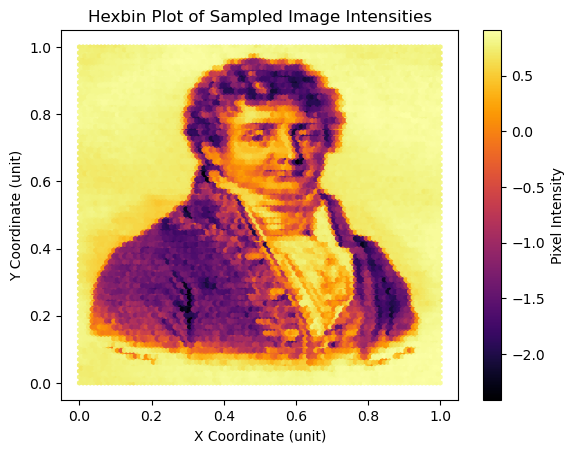

In [4]:
reg = FouriererRegularizer(asset_path="../assets/Joseph_Fourier.jpg", resize_to=512)
N = 200000
xy = torch.rand(N, 2, device=device)   # unit coords in [0,1]
vals = reg.get_joseph(xy)  # (N,)
# use grayscale values as color for hexbin plot``
plt.hexbin(xy[:,0].cpu(), xy[:,1].cpu(), C=vals.cpu(), gridsize=100, cmap='inferno')
plt.colorbar(label='Pixel Intensity')
plt.title('Hexbin Plot of Sampled Image Intensities')
plt.xlabel('X Coordinate (unit)')
plt.ylabel('Y Coordinate (unit)')
plt.show()